# Clinical Plausibility Constraints

Adversarial attacks on image classifiers can perturb pixel values by tiny amounts. The
change is invisible to humans but fools the model. Tabular health data is fundamentally
different. Every feature has a **real-world meaning** and not all perturbations are
physically or clinically possible.

An attack that succeeds by setting a patient's Glucose to -40 mg/dL or BMI to 0.0 is
**clinically meaningless**. No real patient could submit those values. If we count such
attacks as successes our robustness analysis is inflated.

**This section defines the constraint layer that wraps every attack.**
No adversarial example will be accepted as valid unless it passes through this layer.

### Threat Model Assumption
We assume a **black-box, clinically-constrained adversary**:
- Has access to model outputs only (not model weights or training data)
- Can only submit values a real human patient could plausibly have
- Cannot change categorical features to impossible values
- Cannot violate logical dependencies between features

This reflects the most realistic attack scenario: a patient manipulating their own
self-reported or measured clinical data to game a risk screener.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field, asdict
from typing import Optional, List

In [2]:
DATA_DIR = '../data/processed/'
OUTPUT_DIR = '../output/'

diabetes_df = pd.read_csv(os.path.join(DATA_DIR, 'diabetes_processed.csv'))
heart_df    = pd.read_csv(os.path.join(DATA_DIR, 'heart_processed.csv'))
stroke_df   = pd.read_csv(os.path.join(DATA_DIR, 'stroke_processed.csv'))

print(f'  Diabetes : {diabetes_df.shape}')
print(f'  Heart    : {heart_df.shape}')
print(f'  Stroke   : {stroke_df.shape}')

  Diabetes : (768, 9)
  Heart    : (1025, 14)
  Stroke   : (4254, 12)


---
## Constraint Design Principles

Each feature constraint is defined by

| Property | Meaning |
|---|---|
| `min` / `max` | Hard physiological or clinical bounds. Values outside these are impossible |
| `mutable` | Whether an adversary can change this feature at all |
| `is_categorical` | Whether the feature takes only discrete values |
| `allowed_values` | Exact allowed values for categorical features |
| `logical_deps` | Cross-feature constraints (e.g., Pregnancies only valid for females) |

### Three Types of Constraints

**Physiological bounds**: Based on what a living human can have.
e.g., Glucose cannot be negative. BMI below 10 is incompatible with life.

**Categorical rigidity**: Binary or ordinal features do not perturb
continuously. Gender does not shift from 0.0 to 0.3. It is either 0 or 1.

**Logical dependencies**: Some features are only valid given the state
of another. Pregnancies > 0 is only valid for biological females.

In [4]:
# Feature Constraint Class
@dataclass
class FeatureConstraint:
    """
    Defines the clinical plausibility constraints for a single feature.
    Used to validate adversarial examples before accepting them as valid attacks.
    """
    name: str
    min_val: Optional[float]       # Hard lower bound (None = no lower bound)
    max_val: Optional[float]       # Hard upper bound (None = no upper bound)
    mutable: bool                  # Can an adversary perturb this feature?
    is_categorical: bool           # Does it take only discrete values?
    allowed_values: Optional[List] # If categorical, what values are allowed?
    clinical_source: str           # Where this bound comes from
    notes: str = ''                # Any extra reasoning

    def validate(self, value) -> bool:
        """Returns True if a value is clinically plausible."""
        if self.is_categorical and self.allowed_values is not None:
            return value in self.allowed_values
        if self.min_val is not None and value < self.min_val:
            return False
        if self.max_val is not None and value > self.max_val:
            return False
        return True

    def clip(self, value):
        """Clips a continuous value to the valid range."""
        if self.is_categorical:
            raise ValueError(f'{self.name} is categorical — use round/map instead of clip')
        val = value
        if self.min_val is not None:
            val = max(val, self.min_val)
        if self.max_val is not None:
            val = min(val, self.max_val)
        return val

## DIABETES CONSTRAINTS 
Source references used
- WHO Diabetes Diagnosis Criteria (Glucose thresholds)
- CDC BMI Classification Guidelines
- AHA Blood Pressure Guidelines
- Clinical reference ranges for insulin and skin thickness
- PIMA Indians dataset documentation (Lichman, 2013)

In [ ]:
DIABETES_CONSTRAINTS = [

    FeatureConstraint(
        name='Pregnancies',
        # Dataset max is 17. Highest recorded medically is 38, but
        # capping at 20 covers all realistic cases and our data max.
        min_val=0, max_val=20,
        mutable=False,  # An adversary cannot fabricate pregnancy history
        is_categorical=False,
        allowed_values=None,
        clinical_source='PIMA dataset documentation; biological female population only',
        notes='Immutable: this is a historical fact the patient cannot alter on a form'
    ),

    FeatureConstraint(
        name='Glucose',
        # Physiological minimum: below ~40 mg/dL causes unconsciousness (severe hypoglycaemia).
        # A conscious patient submitting a form cannot have glucose < 40.
        # Maximum: above 600 mg/dL is hyperosmolar hyperglycaemic state i.e. patient would be
        # hospitalised, not filling in a risk form. Our data max is 199.
        min_val=40, max_val=400,
        mutable=True,  # KEY: this is the primary attack vector for diabetes evasion
        is_categorical=False,
        allowed_values=None,
        clinical_source='WHO 2006 Diabetes Diagnosis; ADA hypoglycaemia thresholds',
        notes='Primary adversarial target. Underreporting glucose is the most direct evasion.'
    ),

    FeatureConstraint(
        name='BloodPressure',
        # Diastolic BP. Below 40 mmHg = severe shock. Above 140 mmHg = hypertensive crisis.
        # A patient filling in a form will have values in survivable range.
        min_val=40, max_val=140,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='AHA Blood Pressure Guidelines 2017',
        notes='Diastolic BP. Less likely attack vector than Glucose.'
    ),

    FeatureConstraint(
        name='SkinThickness',
        # Triceps skin fold thickness in mm. Physiological range for adults: 5–60mm.
        # Below 5mm is not clinically observed in living adults.
        min_val=5, max_val=80,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='Durnin & Womersley 1974 body fat estimation norms',
        notes='Moderate attack vector. Hard to self-report convincingly.'
    ),

    FeatureConstraint(
        name='Insulin',
        # 2-hour serum insulin. Fasting: 2–25 uIU/mL. Post-meal can reach 200+.
        # Our data has values up to 846 (outliers). Cap at 500 as plausible upper bound.
        min_val=2, max_val=500,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='ADA insulin reference ranges; Tietz Fundamentals of Clinical Chemistry',
        notes='High variance in data. Adversary could plausibly underreport.'
    ),

    FeatureConstraint(
        name='BMI',
        # WHO defines severe underweight as BMI < 16. Below 13 is incompatible with life.
        # Above 80 is extremely rare but documented in severe obesity cases.
        # Our data max is 67.1.
        min_val=13.0, max_val=80.0,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='WHO BMI Classification 2000; clinical case literature',
        notes='Second most likely attack vector after Glucose. Adversary underreports weight.'
    ),

    FeatureConstraint(
        name='DiabetesPedigreeFunction',
        # DPF is a computed score from family history. Range in literature: 0.078–2.42.
        # Immutable because it is derived from genetic family history — cannot be falsified
        # on a form without access to relatives' records.
        min_val=0.05, max_val=2.50,
        mutable=False,
        is_categorical=False,
        allowed_values=None,
        clinical_source='Smith et al. 1988 (original PIMA study); dataset documentation',
        notes='Immutable: derived from verifiable family medical history'
    ),

    FeatureConstraint(
        name='Age',
        # Dataset is restricted to adults 18+. Max in data is 81.
        # Immutable: age is verifiable from identity documents.
        min_val=18, max_val=100,
        mutable=False,
        is_categorical=False,
        allowed_values=None,
        clinical_source='PIMA dataset documentation; dataset age range 21–81',
        notes='Immutable: verifiable from identity documents'
    ),
]

In [6]:
# Build lookup dict for fast access
DIABETES_CONSTRAINTS_DICT = {c.name: c for c in DIABETES_CONSTRAINTS}

print('Diabetes constraints defined:')
print(f'  Total features    : {len(DIABETES_CONSTRAINTS)}')
print(f'  Mutable (attackable): {sum(c.mutable for c in DIABETES_CONSTRAINTS)}')
print(f'  Immutable         : {sum(not c.mutable for c in DIABETES_CONSTRAINTS)}')
mutable = [c.name for c in DIABETES_CONSTRAINTS if c.mutable]
immutable = [c.name for c in DIABETES_CONSTRAINTS if not c.mutable]
print(f'  Mutable features  : {mutable}')
print(f'  Immutable features: {immutable}')

Diabetes constraints defined:
  Total features    : 8
  Mutable (attackable): 5
  Immutable         : 3
  Mutable features  : ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
  Immutable features: ['Pregnancies', 'DiabetesPedigreeFunction', 'Age']


## HEART DISEASE CONSTRAINTS
Source references
- AHA/ACC Heart Disease Guidelines 2019
- Cleveland dataset documentation (Detrano et al. 1989)
- ACC/AHA Cholesterol Guidelines 2018

In [ ]:
HEART_CONSTRAINTS = [

    FeatureConstraint(
        name='Age',
        # Dataset range: 29–77. Immutable.
        min_val=18, max_val=100,
        mutable=False,
        is_categorical=False,
        allowed_values=None,
        clinical_source='Cleveland dataset documentation; verifiable from ID',
    ),

    FeatureConstraint(
        name='sex',
        # Binary: 0=female, 1=male.
        # Immutable: biological sex is verifiable and cannot be continuously perturbed.
        # An attack cannot set sex=0.4 — it must be 0 or 1.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=[0, 1],
        clinical_source='Cleveland dataset coding; binary biological sex',
        notes='Immutable categorical. Critical: cannot be fractionally perturbed.'
    ),

    FeatureConstraint(
        name='cp',
        # Chest pain type: 0=typical angina, 1=atypical angina,
        # 2=non-anginal pain, 3=asymptomatic.
        # Mutable: a patient could misreport their chest pain type.
        # But it must remain one of the four valid categories.
        min_val=None, max_val=None,
        mutable=True,
        is_categorical=True,
        allowed_values=[0, 1, 2, 3],
        clinical_source='Cleveland dataset coding',
        notes='Categorical. Adversary could misrepresent symptom type.'
    ),

    FeatureConstraint(
        name='trestbps',
        # Resting blood pressure (systolic, mmHg). Data range: 94–200.
        # Below 70 = severe shock. Above 250 = extreme hypertensive emergency.
        min_val=70, max_val=250,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='AHA Blood Pressure Guidelines 2017',
        notes='Systolic BP. Adversary could underreport.'
    ),

    FeatureConstraint(
        name='chol',
        # Serum cholesterol mg/dL. Below 100 is extremely rare (abetalipoproteinemia).
        # Above 600 is seen in familial hypercholesterolaemia. Data range: 126–564.
        min_val=100, max_val=650,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='ACC/AHA Cholesterol Guidelines 2018',
        notes='Primary attack vector for heart disease evasion.'
    ),

    FeatureConstraint(
        name='fbs',
        # Fasting blood sugar > 120 mg/dL: 0=False, 1=True.
        # Binary categorical. Cannot be 0.5.
        min_val=None, max_val=None,
        mutable=True,
        is_categorical=True,
        allowed_values=[0, 1],
        clinical_source='Cleveland dataset coding; ADA fasting glucose thresholds',
        notes='Adversary could falsely report normal fasting sugar.'
    ),

    FeatureConstraint(
        name='restecg',
        # Resting ECG results: 0=normal, 1=ST-T wave abnormality, 2=LV hypertrophy.
        # Immutable: determined by objective ECG measurement, not self-report.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=[0, 1, 2],
        clinical_source='Cleveland dataset coding',
        notes='Immutable: objective measurement from ECG machine.'
    ),

    FeatureConstraint(
        name='thalach',
        # Maximum heart rate achieved. Theoretical max ≈ 220 - Age.
        # Min for a living adult during exercise test: ~70 bpm. Data range: 71–202.
        # Immutable: measured during stress test, not self-reported.
        min_val=60, max_val=220,
        mutable=False,
        is_categorical=False,
        allowed_values=None,
        clinical_source='ACSM Exercise Testing Guidelines; dataset range',
        notes='Immutable: objectively measured during supervised exercise test.'
    ),

    FeatureConstraint(
        name='exang',
        # Exercise induced angina: 0=No, 1=Yes.
        # Mutable: patient could misreport chest pain during exercise.
        min_val=None, max_val=None,
        mutable=True,
        is_categorical=True,
        allowed_values=[0, 1],
        clinical_source='Cleveland dataset coding',
        notes='Adversary could deny experiencing angina.'
    ),

    FeatureConstraint(
        name='oldpeak',
        # ST depression induced by exercise relative to rest.
        # 0 = no depression. Negative values are clinically rare but possible (ST elevation).
        # Data range: 0–6.2. Immutable: objective ECG measurement.
        min_val=0.0, max_val=8.0,
        mutable=False,
        is_categorical=False,
        allowed_values=None,
        clinical_source='Cleveland dataset documentation; ECG interpretation standards',
        notes='Immutable: objective ECG measurement.'
    ),

    FeatureConstraint(
        name='slope',
        # Slope of peak exercise ST segment: 0=upsloping, 1=flat, 2=downsloping.
        # Immutable: objective ECG measurement.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=[0, 1, 2],
        clinical_source='Cleveland dataset coding',
        notes='Immutable: objective ECG measurement.'
    ),

    FeatureConstraint(
        name='ca',
        # Number of major vessels (0–3) coloured by fluoroscopy.
        # Immutable: determined by imaging procedure.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=[0, 1, 2, 3, 4],
        clinical_source='Cleveland dataset documentation',
        notes='Immutable: determined by fluoroscopy imaging.'
    ),

    FeatureConstraint(
        name='thal',
        # Thalassemia: 0=normal, 1=fixed defect, 2=reversible defect.
        # Immutable: genetic/diagnostic result from nuclear stress test.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=[0, 1, 2, 3],
        clinical_source='Cleveland dataset coding',
        notes='Immutable: genetic condition confirmed by nuclear imaging.'
    ),
]

In [8]:
HEART_CONSTRAINTS_DICT = {c.name: c for c in HEART_CONSTRAINTS}

print('Heart disease constraints defined:')
print(f'  Total features      : {len(HEART_CONSTRAINTS)}')
print(f'  Mutable (attackable): {sum(c.mutable for c in HEART_CONSTRAINTS)}')
print(f'  Immutable           : {sum(not c.mutable for c in HEART_CONSTRAINTS)}')
mutable = [c.name for c in HEART_CONSTRAINTS if c.mutable]
immutable = [c.name for c in HEART_CONSTRAINTS if not c.mutable]
print(f'  Mutable features    : {mutable}')
print(f'  Immutable features  : {immutable}')

Heart disease constraints defined:
  Total features      : 13
  Mutable (attackable): 5
  Immutable           : 8
  Mutable features    : ['cp', 'trestbps', 'chol', 'fbs', 'exang']
  Immutable features  : ['Age', 'sex', 'restecg', 'thalach', 'oldpeak', 'slope', 'ca', 'thal']


# STROKE CONSTRAINTS
Source references
- WHO Stroke Risk Factor Guidelines
- AHA/ASA Stroke Prevention Guidelines 2021
- Kaggle Stroke dataset documentation

In [9]:
STROKE_CONSTRAINTS = [

    FeatureConstraint(
        name='gender',
        # Categorical: Male / Female / Other.
        # Immutable: verifiable identity attribute.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=['Male', 'Female', 'Other'],
        clinical_source='Dataset documentation',
        notes='Immutable categorical. Cannot be numerically perturbed.'
    ),

    FeatureConstraint(
        name='age',
        # Processed dataset range: 18–82. Immutable.
        min_val=18, max_val=100,
        mutable=False,
        is_categorical=False,
        allowed_values=None,
        clinical_source='Dataset documentation; verifiable from ID',
    ),

    FeatureConstraint(
        name='hypertension',
        # Binary: 0=No, 1=Yes.
        # Immutable: diagnosed medical condition verifiable from records.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=[0, 1],
        clinical_source='ICD-10 hypertension diagnosis codes',
        notes='Immutable: established diagnosis from medical records.'
    ),

    FeatureConstraint(
        name='heart_disease',
        # Binary: 0=No, 1=Yes.
        # Immutable: diagnosed medical condition.
        # Note: in your unified system, this is sometimes imputed from
        # the heart model — that imputation itself could be an attack surface.
        min_val=None, max_val=None,
        mutable=False,
        is_categorical=True,
        allowed_values=[0, 1],
        clinical_source='ICD-10 heart disease diagnosis codes',
        notes='Immutable: established diagnosis. Interesting edge case: imputed from heart model.'
    ),

    FeatureConstraint(
        name='ever_married',
        # Binary: Yes / No. Mutable: self-reported, hard to verify.
        min_val=None, max_val=None,
        mutable=True,
        is_categorical=True,
        allowed_values=['Yes', 'No'],
        clinical_source='Dataset documentation',
        notes='Mutable self-report. Low clinical impact — likely weak attack vector.'
    ),

    FeatureConstraint(
        name='work_type',
        # Categorical: children, Govt_job, Never_worked, Private, Self-employed.
        # Mutable: self-reported employment status.
        min_val=None, max_val=None,
        mutable=True,
        is_categorical=True,
        allowed_values=['children', 'Govt_job', 'Never_worked', 'Private', 'Self-employed'],
        clinical_source='Dataset documentation',
        notes='Mutable. Adversary could misreport work type.'
    ),

    FeatureConstraint(
        name='Residence_type',
        # Binary: Rural / Urban. Mutable: self-reported.
        min_val=None, max_val=None,
        mutable=True,
        is_categorical=True,
        allowed_values=['Rural', 'Urban'],
        clinical_source='Dataset documentation',
        notes='Mutable self-report. Likely weak attack vector.'
    ),

    FeatureConstraint(
        name='avg_glucose_level',
        # Average glucose level mg/dL. Data range: 55–272.
        # Same physiological reasoning as diabetes Glucose feature.
        # This is SHARED with the diabetes model in your unified system.
        min_val=40, max_val=400,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='WHO Diabetes Diagnosis; ADA hypoglycaemia thresholds',
        notes='Primary attack vector. Same feature as Glucose in diabetes model.'
    ),

    FeatureConstraint(
        name='bmi',
        # BMI. Data range: 10.3–97.6. Same reasoning as diabetes BMI.
        min_val=13.0, max_val=80.0,
        mutable=True,
        is_categorical=False,
        allowed_values=None,
        clinical_source='WHO BMI Classification 2000',
        notes='Second most likely attack vector. Adversary underreports weight.'
    ),

    FeatureConstraint(
        name='smoking_status',
        # Categorical: formerly smoked, never smoked, smokes, Unknown.
        # Mutable: self-reported. A smoker could claim never smoked.
        # This is a meaningful attack vector because smoking significantly
        # increases stroke risk.
        min_val=None, max_val=None,
        mutable=True,
        is_categorical=True,
        allowed_values=['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
        clinical_source='Dataset documentation; AHA stroke risk factors',
        notes='HIGH RISK attack vector. Smoker claiming never smoked is a realistic evasion.'
    ),
]


In [10]:
STROKE_CONSTRAINTS_DICT = {c.name: c for c in STROKE_CONSTRAINTS}

print('Stroke constraints defined:')
print(f'  Total features      : {len(STROKE_CONSTRAINTS)}')
print(f'  Mutable (attackable): {sum(c.mutable for c in STROKE_CONSTRAINTS)}')
print(f'  Immutable           : {sum(not c.mutable for c in STROKE_CONSTRAINTS)}')
mutable = [c.name for c in STROKE_CONSTRAINTS if c.mutable]
immutable = [c.name for c in STROKE_CONSTRAINTS if not c.mutable]
print(f'  Mutable features    : {mutable}')
print(f'  Immutable features  : {immutable}')

Stroke constraints defined:
  Total features      : 10
  Mutable (attackable): 6
  Immutable           : 4
  Mutable features    : ['ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
  Immutable features  : ['gender', 'age', 'hypertension', 'heart_disease']


## The Constraint Validator

Before any adversarial example is counted as a valid attack, it must pass
through this validator. If it fails the attack is discarded as clinically
implausible, regardless of whether it fooled the model.

In [11]:
def validate_adversarial_example(original: dict,
                                  perturbed: dict,
                                  constraints: dict) -> dict:
    """
    Validates whether a perturbed input is clinically plausible.

    Args:
        original   : Original patient feature values
        perturbed  : Adversarially perturbed feature values
        constraints: Dict of {feature_name: FeatureConstraint}

    Returns:
        {
          'valid': bool,
          'violations': list of violation descriptions,
          'clipped': dict of clipped-to-valid perturbed values
        }
    """
    violations = []
    clipped = dict(perturbed)  # start with perturbed, clip where needed

    for feat, constraint in constraints.items():
        if feat not in perturbed:
            continue

        orig_val = original.get(feat)
        pert_val = perturbed[feat]

        # Rule 1: Immutable features must not change
        if not constraint.mutable:
            if orig_val != pert_val:
                violations.append(
                    f"IMMUTABLE VIOLATION: '{feat}' changed from {orig_val} to {pert_val}"
                )
                clipped[feat] = orig_val  # restore original
            continue

        # Rule 2: Categorical features must stay within allowed values
        if constraint.is_categorical:
            if not constraint.validate(pert_val):
                violations.append(
                    f"CATEGORICAL VIOLATION: '{feat}' = {pert_val} "
                    f"not in {constraint.allowed_values}"
                )
                clipped[feat] = orig_val  # restore original if invalid
            continue

        # Rule 3: Continuous features must stay within physiological bounds
        if not constraint.validate(pert_val):
            clipped_val = constraint.clip(pert_val)
            violations.append(
                f"BOUNDS VIOLATION: '{feat}' = {pert_val:.2f} "
                f"outside [{constraint.min_val}, {constraint.max_val}] "
                f"→ clipped to {clipped_val:.2f}"
            )
            clipped[feat] = clipped_val

    return {
        'valid': len(violations) == 0,
        'violations': violations,
        'clipped': clipped
    }

In [12]:
def apply_constraints_to_array(X_adv: np.ndarray,
                                X_orig: np.ndarray,
                                feature_names: list,
                                constraints_dict: dict) -> np.ndarray:
    """
    Applies constraint clipping to an entire array of adversarial examples.
    Used to post-process outputs from ART or custom attack implementations.

    Args:
        X_adv         : Adversarial examples array (n_samples, n_features)
        X_orig        : Original inputs array (n_samples, n_features)
        feature_names : List of feature names matching column order
        constraints_dict: Dict of {feature_name: FeatureConstraint}

    Returns:
        X_constrained : Clipped adversarial examples (n_samples, n_features)
    """
    X_constrained = X_adv.copy()

    for i, feat in enumerate(feature_names):
        if feat not in constraints_dict:
            continue
        constraint = constraints_dict[feat]

        if not constraint.mutable:
            # Restore original values for immutable features
            X_constrained[:, i] = X_orig[:, i]
        elif not constraint.is_categorical:
            # Clip continuous mutable features to valid range
            if constraint.min_val is not None:
                X_constrained[:, i] = np.maximum(X_constrained[:, i], constraint.min_val)
            if constraint.max_val is not None:
                X_constrained[:, i] = np.minimum(X_constrained[:, i], constraint.max_val)

    return X_constrained

Before I trust these constraints, I verify them against the actual datasets.
Any real data points that violate my bounds indicate either data quality issues
or overly tight constraints that need revisiting.

In [13]:
def check_constraints_against_data(df, constraints, dataset_name, target_col):
    """
    Checks how many real data points would violate our defined constraints.
    Any violations suggest the constraint bounds need adjustment.
    """
    print(f'\n=== {dataset_name} Constraint Sanity Check ===')
    features = [c for c in constraints if c.name in df.columns]

    results = []
    for constraint in features:
        col = constraint.name
        if constraint.is_categorical:
            if constraint.allowed_values:
                violations = (~df[col].isin(constraint.allowed_values)).sum()
                print(f'  {col:35s} | categorical | violations: {violations}')
        else:
            below = (df[col] < constraint.min_val).sum() if constraint.min_val is not None else 0
            above = (df[col] > constraint.max_val).sum() if constraint.max_val is not None else 0
            mut = 'MUTABLE  ' if constraint.mutable else 'immutable'
            flag = ' ← REVIEW' if (below + above) > 0 else ''
            print(
                f'  {col:35s} | {mut} | '
                f'range [{constraint.min_val}, {constraint.max_val}] | '
                f'data [{df[col].min():.1f}, {df[col].max():.1f}] | '
                f'violations: {below+above}{flag}'
            )
        results.append({'feature': col, 'violations': 0})

# Run for all three datasets
check_constraints_against_data(
    diabetes_df, DIABETES_CONSTRAINTS, 'DIABETES', 'Outcome'
)
check_constraints_against_data(
    heart_df, HEART_CONSTRAINTS, 'HEART DISEASE', 'target'
)
check_constraints_against_data(
    stroke_df, STROKE_CONSTRAINTS, 'STROKE', 'stroke'
)


=== DIABETES Constraint Sanity Check ===
  Pregnancies                         | immutable | range [0, 20] | data [0.0, 17.0] | violations: 0
  Glucose                             | MUTABLE   | range [40, 400] | data [44.0, 199.0] | violations: 0
  BloodPressure                       | MUTABLE   | range [40, 140] | data [24.0, 122.0] | violations: 4 ← REVIEW
  SkinThickness                       | MUTABLE   | range [5, 80] | data [7.0, 99.0] | violations: 1 ← REVIEW
  Insulin                             | MUTABLE   | range [2, 500] | data [14.0, 846.0] | violations: 9 ← REVIEW
  BMI                                 | MUTABLE   | range [13.0, 80.0] | data [18.2, 67.1] | violations: 0
  DiabetesPedigreeFunction            | immutable | range [0.05, 2.5] | data [0.1, 2.4] | violations: 0
  Age                                 | immutable | range [21, 100] | data [21.0, 81.0] | violations: 0

=== HEART DISEASE Constraint Sanity Check ===
  Age                                 | immutable | r

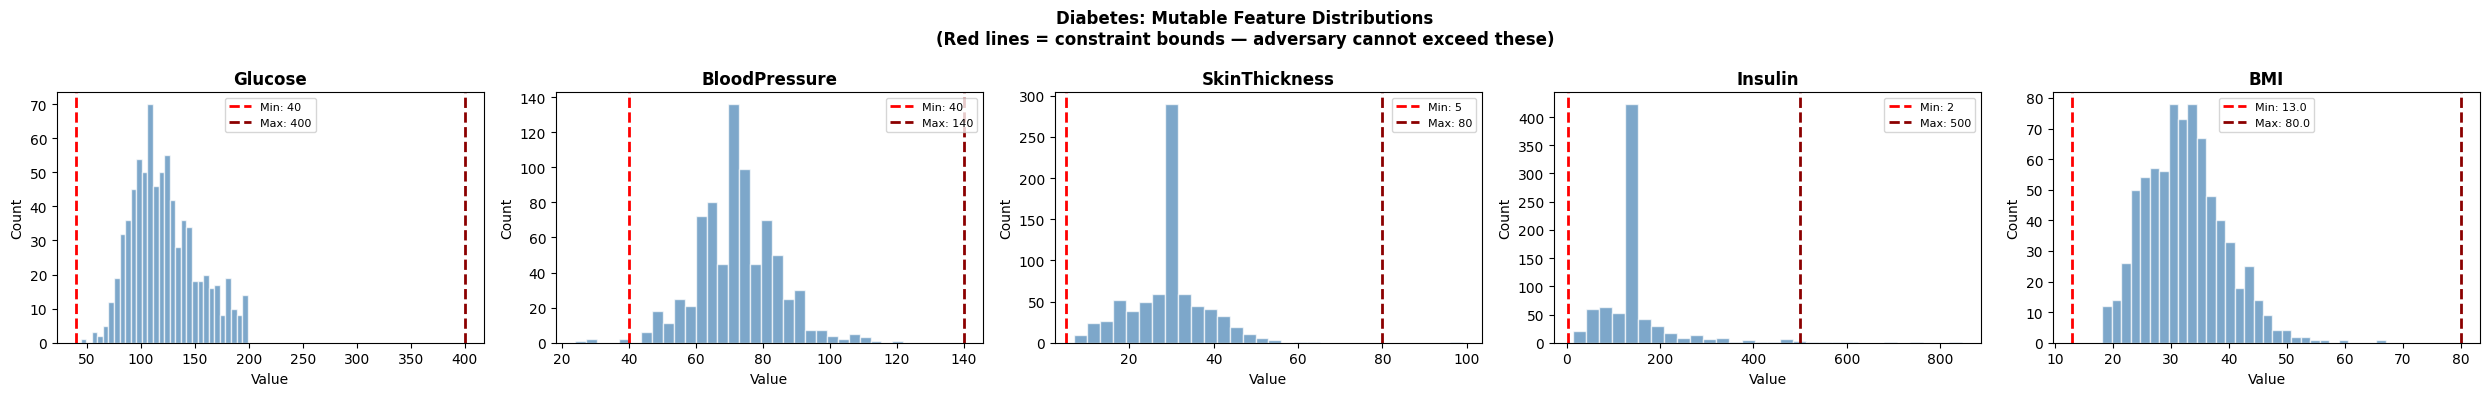

Saved: output/diabetes_attack_surface.png


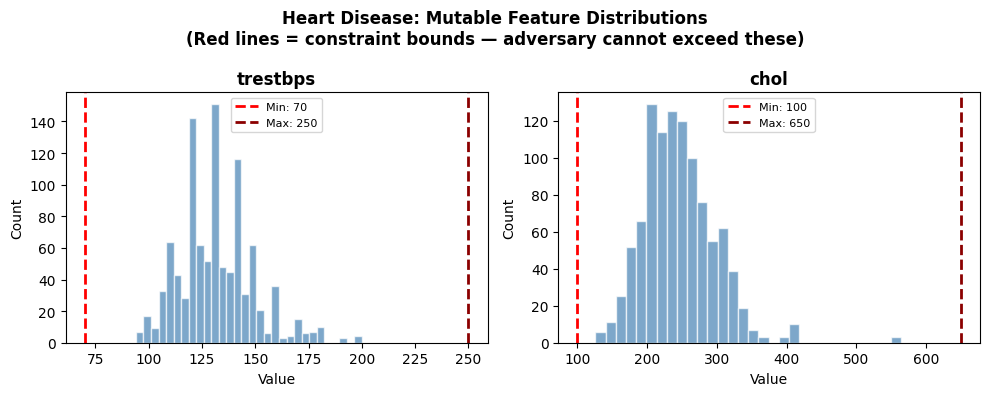

Saved: output/heart_disease_attack_surface.png


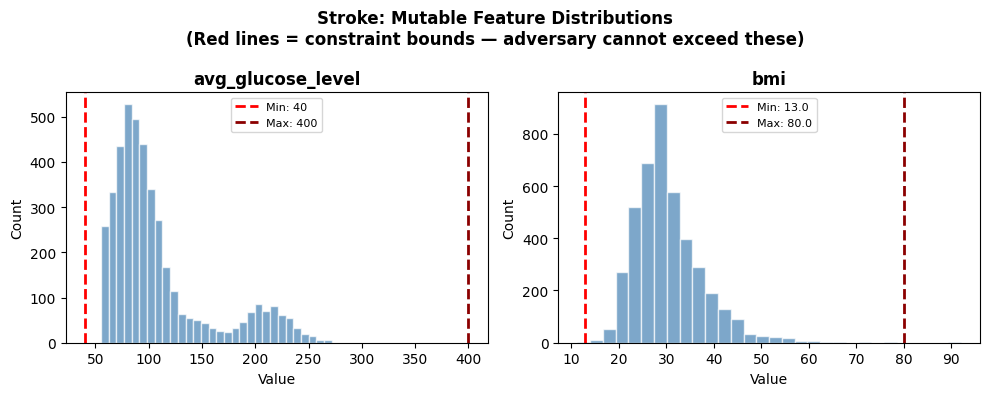

Saved: output/stroke_attack_surface.png


In [14]:
def plot_mutable_feature_distributions(df, constraints, dataset_name, target_col):
    """
    Plots distributions of mutable continuous features with constraint bounds overlaid.
    Red dashed lines = constraint boundaries (attack limits).
    """
    mutable_continuous = [
        c for c in constraints
        if c.mutable and not c.is_categorical and c.name in df.columns
    ]

    if not mutable_continuous:
        print(f'No mutable continuous features in {dataset_name}')
        return

    n = len(mutable_continuous)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    fig.suptitle(
        f'{dataset_name}: Mutable Feature Distributions\n'
        f'(Red lines = constraint bounds — adversary cannot exceed these)',
        fontsize=12, fontweight='bold'
    )

    for ax, constraint in zip(axes, mutable_continuous):
        col = constraint.name
        ax.hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='white')

        if constraint.min_val is not None:
            ax.axvline(constraint.min_val, color='red', linestyle='--',
                       linewidth=2, label=f'Min: {constraint.min_val}')
        if constraint.max_val is not None:
            ax.axvline(constraint.max_val, color='darkred', linestyle='--',
                       linewidth=2, label=f'Max: {constraint.max_val}')

        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'../output/{dataset_name.lower().replace(" ", "_")}_attack_surface.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: output/{dataset_name.lower().replace(" ", "_")}_attack_surface.png')


plot_mutable_feature_distributions(diabetes_df, DIABETES_CONSTRAINTS, 'Diabetes', 'Outcome')
plot_mutable_feature_distributions(heart_df,    HEART_CONSTRAINTS,    'Heart Disease', 'target')
plot_mutable_feature_distributions(stroke_df,   STROKE_CONSTRAINTS,   'Stroke', 'stroke')

In [15]:
def constraints_to_json(constraints: list) -> list:
    """Converts list of FeatureConstraint objects to JSON-serialisable format."""
    result = []
    for c in constraints:
        result.append({
            'name': c.name,
            'min_val': c.min_val,
            'max_val': c.max_val,
            'mutable': c.mutable,
            'is_categorical': c.is_categorical,
            'allowed_values': c.allowed_values,
            'clinical_source': c.clinical_source,
            'notes': c.notes
        })
    return result


constraints_payload = {
    'diabetes': constraints_to_json(DIABETES_CONSTRAINTS),
    'heart':    constraints_to_json(HEART_CONSTRAINTS),
    'stroke':   constraints_to_json(STROKE_CONSTRAINTS),
    'metadata': {
        'description': 'Clinical plausibility constraints for adversarial robustness analysis',
        'threat_model': 'Black-box, clinically-constrained adversary',
        'version': '1.0'
    }
}

output_path = os.path.join(OUTPUT_DIR, 'clinical_constraints.json')
with open(output_path, 'w') as f:
    json.dump(constraints_payload, f, indent=2)

print(f'Constraints saved to: {output_path}')

# Verify by reloading
with open(output_path, 'r') as f:
    loaded = json.load(f)

print(f'\nVerification — features saved per dataset:')
for dataset in ['diabetes', 'heart', 'stroke']:
    print(f'  {dataset}: {len(loaded[dataset])} features')

Constraints saved to: ../output/clinical_constraints.json

Verification — features saved per dataset:
  diabetes: 8 features
  heart: 13 features
  stroke: 10 features
